# Model Setup and Loading

texto x

In [1]:
import sys

# Add project root in the path
sys.path.append('..')

In [2]:
from src.model_utils import load_model_and_tokenizer

model, tokenizer = load_model_and_tokenizer('gpt2')

w:\Github\logit-lens-vs-tuned-lens\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 14113.57it/s]


# Data Extraction

textp x

In [3]:
import pandas as pd

# Load data
df_prompts = pd.read_csv('prompts_benchmark.txt', sep='\t')

df_prompts = df_prompts.sample(frac=1).reset_index(drop=True) # Disorganize data

df_prompts.head()

,category,prompt,target
0,logic,"A, B, C, D,",E
1,logic,Left is the opposite of,right
2,grammar,I have known him for a very long,time
3,logic,"First, second, third,",fourth
4,common sense,"When you are very thirsty, you should",drink


explicar que el benchmark el target no es exactamente la prediccion sino lo que se esperaria realmente, entonces se va a mirar cuantos targets coinciden con la prediccion real y crear un dataframe solo con estos

In [4]:
import torch

correct_predictions = 0
total_prompts = len(df_prompts)

model.eval() # Evaluation mode

correct_prompts = []

for index, row in df_prompts.iterrows():
    prompt = row['prompt']
    target = row['target']
    
    # Take tokenizer input
    inputs = tokenizer(prompt, return_tensors="pt")
    
    # Calculate output
    with torch.no_grad():
        outputs = model(**inputs)

    next_token_id = outputs.logits[0, -1, :].argmax(dim=-1).item()
    predicted_text = tokenizer.decode(next_token_id) # Get next word
    
    # Check if target matches with the prediction
    if predicted_text == target:
        correct_predictions += 1
        correct_prompts.append(row)
    
# Make new data frame
df_filtred = pd.DataFrame(correct_prompts).reset_index(drop=True)

print(f"Correct predictions: {correct_predictions} / {total_prompts}")

Correct predictions: 32 / 90


In [5]:
df_filtred.head()

,category,prompt,target
0,logic,"A, B, C, D,",E
1,grammar,I have known him for a very long,time
2,logic,"First, second, third,",fourth
3,common sense,"When you are very thirsty, you should",drink
4,common sense,You use a pen or pencil to,write


# Analysis of the Kullback-Leibler Divergence

explicar este metrica

In [6]:
from src.notebooks_utils import calculate_kl_divergence

from src.logit_lens import get_all_logit_lens_logits
from src.tuned_lens import get_all_tuned_lens_logits, SingleLayerTunedLens

import torch.nn as nn

num_layers = model.config.n_layer

# Total sum of kl divergence per layer
kl_div_sums_logit = {layer: 0.0 for layer in range(1, num_layers + 1)} 
kl_div_sums_tuned = {layer: 0.0 for layer in range(1, num_layers + 1)}

total_prompts = len(df_filtred)

# Import lenses

# Structure from lenses
hidden_size = model.config.n_embd
device = 'cpu'

lenses = nn.ModuleDict({
    str(layer_idx): SingleLayerTunedLens(hidden_size)
    for layer_idx in range(1, num_layers)
})

# Load weights saved
lenses.load_state_dict(torch.load('..\checkpoints/all_tuned_lenses.pt', map_location=device))
lenses.to(device)

lenses.eval()

# 
model.eval()
vocab_size = tokenizer.vocab_size

for index, row in df_filtred.iterrows():
    prompt = row['prompt']
    
    # Use function to get logits and final logits
    layer_logits_dict_logit = get_all_logit_lens_logits(model, tokenizer, prompt)
    layer_logits_dict_tuned = get_all_tuned_lens_logits(model, tokenizer, lenses, prompt)
    
    final_logits = layer_logits_dict_logit[num_layers]
    
    # Calculate kl div for each layer
    for layer_idx in range(1, num_layers + 1):
        layer_logits_logit = layer_logits_dict_logit[layer_idx]
        layer_logits_tuned = layer_logits_dict_tuned[layer_idx]
        
        # KL divergence for Logit Lens
        kl_val_logit = calculate_kl_divergence(layer_logits_logit.unsqueeze(0), final_logits.unsqueeze(0)) # Adjust the dimensions
        
        # KL divergence for Tuned Lens
        kl_val_tuned = calculate_kl_divergence(layer_logits_tuned.unsqueeze(0), final_logits.unsqueeze(0)) # Adjust the dimensions
        
        # Storage kl values
        kl_div_sums_logit[layer_idx] += kl_val_logit.item()
        kl_div_sums_tuned[layer_idx] += kl_val_tuned.item()
        
# Get average
kl_div_avg_logit = {layer: (kl_div_sums_logit[layer] / total_prompts) for layer in range(1, num_layers + 1)}
kl_div_avg_tuned = {layer: (kl_div_sums_tuned[layer] / total_prompts) for layer in range(1, num_layers + 1)}

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6472\2512387107.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lenses.load_state_dict(torch.load('..\checkpoints/all_tuned_l

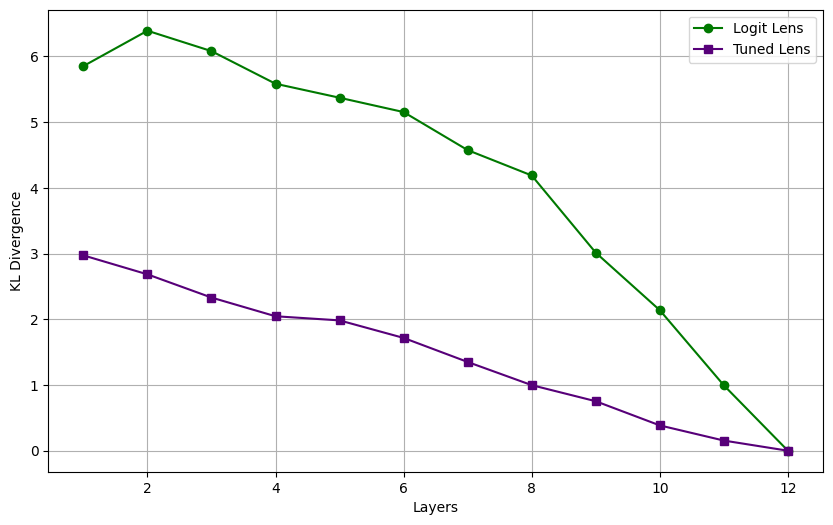

In [7]:
import matplotlib.pyplot as plt

layers = list(kl_div_avg_logit.keys())
logit_values = list(kl_div_avg_logit.values())
tuned_values = list(kl_div_avg_tuned.values())

# Graph
plt.figure(figsize=(10, 6))

plt.plot(layers, logit_values, label='Logit Lens', marker='o', color="#007900")
plt.plot(layers, tuned_values, label='Tuned Lens', marker='s', color="#570079")

plt.xlabel('Layers')
plt.ylabel('KL Divergence')

plt.grid()

plt.legend()
plt.show()

# Analysis of the Mean Reciprocal Rank

explicar tambien esta mierda

In [8]:
from src.notebooks_utils import calculate_reciprocal_rank

rr_logit = {layer:0.0 for layer in range(1, num_layers + 1)}
rr_tuned = {layer:0.0 for layer in range(1, num_layers + 1)}

for index, row in df_filtred.iterrows():
    prompt = row['prompt'] # Get prompt
    target = row['target'] # Get target
    
    target_token_id = tokenizer.encode(target)[0] # Get target id
    
    # Use function to get logits
    layer_logits_dict_logit = get_all_logit_lens_logits(model, tokenizer, prompt)
    layer_logits_dict_tuned = get_all_tuned_lens_logits(model, tokenizer, lenses, prompt)
    
    for layer in range(1, num_layers + 1):
        actual_layer_logit = layer_logits_dict_logit[layer]
        actual_layer_tuned = layer_logits_dict_tuned[layer]
        
        reciprocal_rank_logit, _ = calculate_reciprocal_rank(actual_layer_logit, target_token_id)
        reciprocal_rank_tuned, _ = calculate_reciprocal_rank(actual_layer_tuned, target_token_id)
        
        rr_logit[layer] += reciprocal_rank_logit
        rr_tuned[layer] += reciprocal_rank_tuned
        
mrr_logit = {layer: (rr_logit[layer] / total_prompts) for layer in range(1, num_layers + 1)}
mrr_tuned = {layer: (rr_tuned[layer] / total_prompts) for layer in range(1, num_layers + 1)}

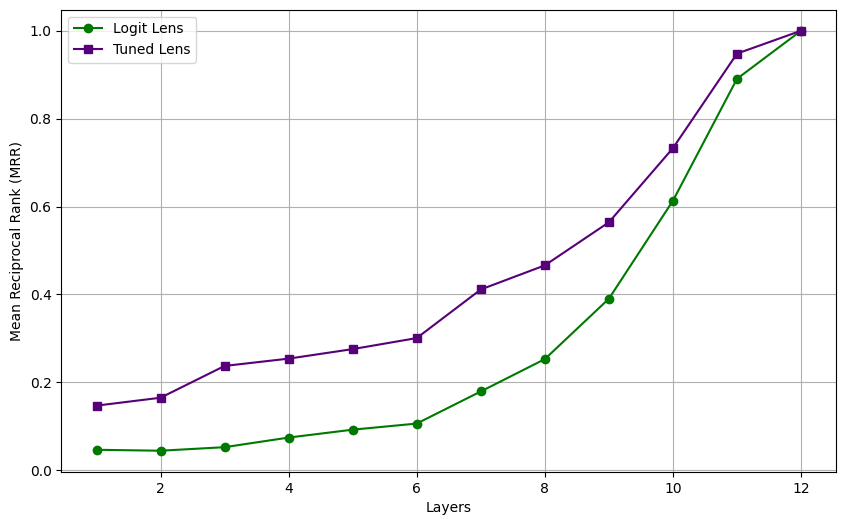

In [9]:
layers = list(mrr_logit.keys())
mrr_logit_values = list(mrr_logit.values())
mrr_tuned_values = list(mrr_tuned.values())

# Graph
plt.figure(figsize=(10, 6))

plt.plot(layers, mrr_logit_values, label='Logit Lens', marker='o',color="#007900")
plt.plot(layers, mrr_tuned_values, label='Tuned Lens', marker='s',color="#570079")

plt.xlabel('Layers')
plt.ylabel('Mean Reciprocal Rank (MRR)')

plt.grid()

plt.legend()
plt.show()

# Analysis of the Initial Token Offering Layer

texto x

In [ ]:
from src.logit_lens import run_logit_lens
from src.tuned_lens import run_tuned_lens

CDF_logit = {layer:0.0 for layer in range(1, num_layers + 1)}
CDF_tuned = {layer:0.0 for layer in range(1, num_layers + 1)}

num_prompts = df_filtred.shape[0]

for index, row in df_filtred.iterrows():
    prompt = row['prompt']
    target = row['target']
    
    # Use function to get logits
    layer_dict_logit = run_logit_lens(model, tokenizer, prompt, top_k=1)
    layer_dict_tuned = run_tuned_lens(model, tokenizer, lenses, prompt, top_k=1)
    
    for layer in range(1, num_layers + 1):
        [(word_predicted_logit, _)] = layer_dict_logit[layer]
        [(word_predicted_tuned, _)] = layer_dict_tuned[layer]
        
        # Acummulate the correct predictions
        if target == word_predicted_logit: CDF_logit[layer] += 1.0 / num_prompts
            
        if target == word_predicted_tuned: CDF_tuned[layer] += 1.0 / num_prompts

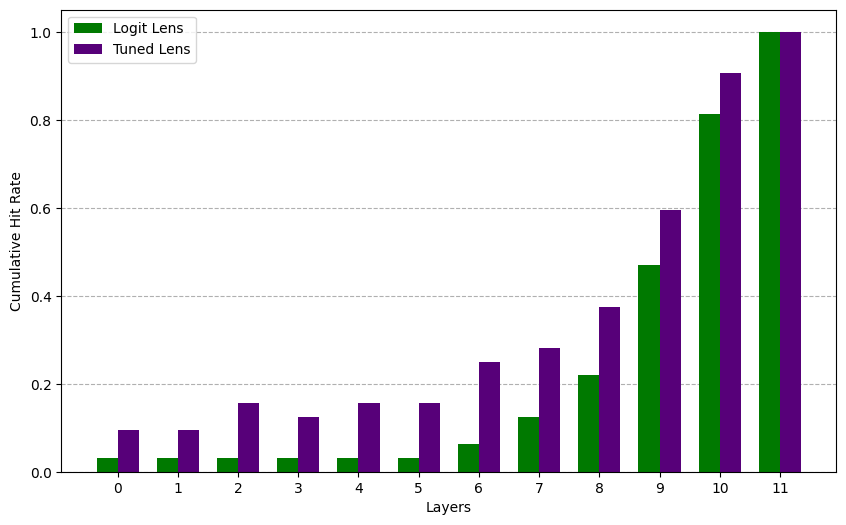

In [37]:
import numpy as np

layers = list(CDF_logit.keys())
CDF_logit_values = list(CDF_logit.values())
CDF_tuned_values = list(CDF_tuned.values())

x = np.arange(len(layers))
width = 0.35

# Graph
fig, ax = plt.subplots(figsize=(10, 6))

bars_logit = ax.bar(x - width/2, CDF_logit_values, width, label='Logit Lens', color='#007900')
bars_tuned = ax.bar(x + width/2, CDF_tuned_values, width, label='Tuned Lens', color='#570079')

ax.set_xlabel('Layers')
ax.set_ylabel('Cumulative Hit Rate')

ax.set_axisbelow(True)
ax.set_xticks(x)

ax.yaxis.grid(linestyle='--')

ax.legend()
plt.show()